### (Contextual) No Regret Dynamics

`ContextualFTLDynamics` implements no-regret dynamics among $n$ players, when the game can change from one period to the next.

`context_sequence` specifies the sequence of contexts that players observe. If `context_sequence` is constant, the game is fixed.

#### Public vs private info

Public info: players' observable info is $(\alpha, \beta, S, V, r)$

Private info: player $i$'s observable info is $(\alpha, \beta, S, V_i, r_i)$

#### Regret calculations

Public info (regret computed wrt full info): 

- for player $i$ and context $x$, `per_context_regrets[i][x][R]` = $\sum_{r:x^r = x} c_i(h_i^r, h_{-i}^r, x^r) - \min_{h_i^*} \sum_{r:x^r = x}  c_i(h_i^*, h_{-i}^r, x^r)$

- for player $i$, `contextual_regrets[i][R]` = $\sum_{r=1}^R c_i(h_i^r, h_{-i}^r, x^r) - \min_{\phi: X \to H} \sum_{r=1}^R c_i(\phi(x^r), h_{-i}^r, x^r)$

(Note: when context is fixed , contextual regret corresponds to normal regret.)

Private info (regret computed wrt observable info):

- for player $i$ and context $x$, `private_per_context_regrets[i][x][R]` = $\sum_{r:x_i^r = x} c_i(h_i^r, h_{-i}^r, x^r) - \min_{h_i^*} \sum_{x_i^r = x} c_i(h_i^*, h_{-i}^r, x^r)$

- for player $i$, `private_contextual_regrets[i][R]` = $\sum_{r=1}^R c_i(h_i^r, h_{-i}^r, x^r) - \min_{\phi: X_i \to H} \sum_{r=1}^R c_i(\phi(x_i^r), h_{-i}^r, x^r)$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ftl import ContextualFTLDynamics, get_last_iterate_strategies
from algorithms import extra_gradient_equilibrium

n = 2
T = 10
alpha = 1 # permanent impact
beta = 1 # temporary impact
S = np.zeros(T)
Vs = [20, 10]
# rs = [50, 50]
rs = None
num_iter = 100 # number of periods of no-regret dynamics

# Create context list
context_list = []
context_list.append({"n": n, "T": T, "p_0": 0, "Vs": [50, 80], "alpha": alpha, "beta": beta, "supply": S, "reserve": rs, "exp": 1})
context_list.append({"n": n, "T": T, "p_0": 0, "Vs": [50, 20], "alpha": alpha, "beta": beta, "supply": S, "reserve": rs, "exp": 1})
# context_list.append({"n": n, "T": T, "p_0": 0, "Vs": [50, 50], "alpha": alpha, "beta": beta, "supply": S, "reserve": rs, "exp": 1})

# context_sequence = np.zeros(num_iter, dtype=int)  # fixed context sequence
context_sequence = np.random.randint(0, len(context_list), num_iter) # random context sequence
    
# Run using contextual algorithm
game = ContextualFTLDynamics(context_list, private_info=True)
actions, costs, per_context_regrets, contextual_regrets, private_per_context_regrets, private_contextual_regrets = game.run(context_sequence, num_iter=num_iter)

colors = ['#4B89DC', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#34495E', '#16A085', '#D35400', '#8E44AD', '#2C3E50']

# Find last iterate (approx Bayes NE) strategies for each context
last_iterate_strategies = get_last_iterate_strategies(game, actions, context_sequence)

# Find NE strategies for each game
NE_demands = []
for game_dict in context_list:
    if game_dict["reserve"] is None:
        game_dict["reserve"] = [100000 for _ in range(n)]
    NE_demands.append(extra_gradient_equilibrium(game_dict))

Contextual FTL: 100%|██████████| 100/100 [00:12<00:00,  7.99it/s]


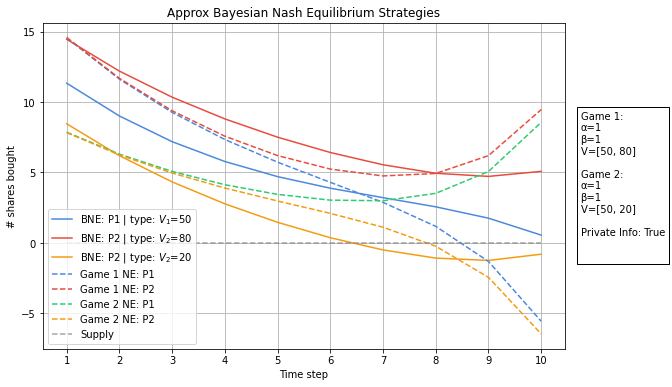

In [2]:
# Compare BNE and NE strategies
plt.figure(figsize=(10,6))
for i in range(len(last_iterate_strategies)):
    for j, strategy in enumerate(last_iterate_strategies[i]):
        mapping_values = list(game.player_context_mapping[i].values())
        types = context_list[mapping_values[j]]['Vs']
        plt.plot(strategy, label=f'BNE: P{i+1} | type: $V_{i+1}$={types[i]}', color=colors[i+j*n]) 
for j, NE_demand in enumerate(NE_demands):
    for i in range(n):
        plt.plot(NE_demand[i], '--', color=colors[i+j*n],
                label=f'Game {j+1} NE: P{i+1}')
plt.plot(S, '--', color='gray', label='Supply', alpha=0.7)
plt.xticks(range(T), range(1, T+1))
plt.xlabel('Time step')
plt.ylabel('# shares bought')
plt.title(f'Approx Bayesian Nash Equilibrium Strategies')
plt.legend()
plt.grid(True)
# Add text box with game parameters
param_text = ""
for i, game_dict in enumerate(context_list):
    param_text += f"Game {i+1}:\n"
    param_text += f"α={game_dict['alpha']}\n"
    param_text += f"β={game_dict['beta']}\n" 
    param_text += f"V={[v for v in game_dict['Vs']]}\n\n"
param_text += f"Private Info: {game.private_info}\n\n"
plt.text(1.03, 0.5, param_text, transform=plt.gca().transAxes, bbox=dict(facecolor='white'), verticalalignment='center')
plt.subplots_adjust(right=0.85)
plt.show()

In [3]:
import matplotlib.animation as animation
def animate(T, game_dict, actions, NE_demand, colors, save_animation=False):
    """Creates an animation showing the evolution of FTL dynamics.
    
    Args:
        T (int): Number of time periods
        game_dict (dict): Dictionary containing game parameters
        actions (list): List of lists containing each player's actions over iterations
        NE_demand (array): Nash equilibrium strategies for all players
        
    Returns:
        IPython.display.HTML: Animation showing FTL dynamics evolution
    """
    n = game_dict["n"]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10,6))

    # Initialize empty lines for each player
    lines = []
    for i in range(n):
        line, = ax.plot([], [], color=colors[i], label=f'P{i+1} action')
        lines.append(line)

    # Set axis limits
    ax.set_xlim(-0.5, T-0.5)
    ymin = min([min([min(actions[i][j]) for j in range(len(actions[i]))]) for i in range(n)])
    ymax = max([max([max(actions[i][j]) for j in range(len(actions[i]))]) for i in range(n)])
    ax.set_ylim(ymin - 0.1*(ymax-ymin), ymax + 0.1*(ymax-ymin))

    # Set labels and title
    ax.set_xticks(range(T))
    ax.set_xticklabels(range(1, T+1))
    ax.set_xlabel('Time step')
    ax.set_ylabel('# shares bought')
    param_str = f'T={T}, α={game_dict["alpha"]}, β={game_dict["beta"]}, V_i={game_dict["Vs"]}'
    if game_dict["reserve"] is not None:
        param_str += ', ' + f'reserves={game_dict["reserve"]}'
    ax.set_title(f'FTL Dynamics Evolution\n{param_str}')
    ax.grid(True)
    ax.legend()

    # Add NE strategies as static lines
    for i in range(n):
        for j, NE_demand in enumerate(NE_demands):
            plt.plot(NE_demand[i], '--', color=colors[i+j*n], alpha=0.7,
                    label=f'P{i+1} context {j+1}')
    ax.legend()

    # Add supply as static line
    ax.plot(S, '--', color='gray', label='Supply', alpha=0.7)
    ax.legend()

    # Initialize text annotation
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    def animate(frame):
        for i in range(n):
            lines[i].set_data(range(T), actions[i][frame])
        time_text.set_text(f'Iteration: {frame}')
        return tuple(lines) + (time_text,)

    from IPython.display import HTML
    anim = animation.FuncAnimation(fig, animate, frames=len(actions[0]),
                                 interval=100, blit=True)
    
    if save_animation:
        # Save animation as MP4
        anim_name = f"ftl_n{n}_T{T}_alpha{game_dict['alpha']}_beta{game_dict['beta']}.mp4"
        writervideo = animation.FFMpegWriter(fps=10) 
        anim.save(anim_name, writer=writervideo)
        print(f"Animation saved as {anim_name}")

    plt.close()
    return HTML(anim.to_jshtml())
animate(T, game_dict, actions, NE_demand, colors, save_animation=False)
